In [1]:
import os
from scipy.io import loadmat
import numpy as np
# Ruta del archivo que se quiera cargar
home_dir = os.path.expanduser("~")
DataSimCianos = os.path.join(home_dir, "Desktop", "Spline Optimizer", "Saves", "simulationSol-E8.mat")

# Cargar el archivo MAT
data = loadmat(DataSimCianos)  # Aquí cargamos el archivo realmente

# Mostrar las claves (variables almacenadas en el archivo)
#print(data.keys())

# Acceder a una tabla específica por su clave (reemplaza 'nombre_tabla' por la clave real)
IDLogs = data["IDLog"] #Dimensiones: [instantes de tiempo x nº máx de partículas en algún instante] ej: [187x612]
#print("Tabla IDLogs: \n", IDLogs) 
parentCell = data["parentCell"] #Dimensiones: [1 x nº total de partículas que aparecen en la simulación] ej: [1x1261]
#print("Tabla parentCell: \n", parentCell)
tVec = data["tVec"] #Dimensiones [1 x instantes de tiempo] ej: [1x187]
#tVec está en dias, lo pasamos a minutos
tVec_min = tVec*24*60
#print("Tabla tVec", tVec)
xCellLog = data["xCellLog"] #Dimensiones [instantes de tiempo x nº máximo de partículas en algún instante x (x, y, z)] ej: [187x612x3]
#print("Tabla xCellLog: \n", xCellLog)


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from pymoo.core.mutation import Mutation
from pymoo.core.crossover import Crossover
from pymoo.core.sampling import Sampling
from pymoo.core.population import Population
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.algorithms.moo.nsga2 import binary_tournament
from pymoo.operators.survival.rank_and_crowding.metrics import calc_crowding_distance
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2

from pymoo.algorithms.soo.nonconvex.brkga import EliteSurvival

from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

from pymoo.operators.survival.rank_and_crowding import RankAndCrowding
from pymoo.core.survival import Survival

from pymoo.termination.default import DefaultMultiObjectiveTermination





# # === Muestreo personalizado ===


# class CustomSampling(Sampling):
#     def __init__(self, punto_ini, punto_fin):
#         super().__init__()
#         self.punto_ini = punto_ini
#         self.punto_fin = punto_fin

#     def _do(self, problem, n_samples, **kwargs):
#         samples = np.zeros((n_samples, problem.n_var))  # Matriz de muestras [Población x Variables]
        
#         for i in range(n_samples):
#             sample = []
#             sample.extend(self.punto_ini)
#             #print(self.punto_ini)
#             for j in range(3, problem.n_var-3, 3):  # Iterar en pasos de 3 (x, y, z)
#                     x = np.random.uniform(problem.xl[j], problem.xu[j])   # Generar X dentro del rango
#                     y = np.random.uniform(problem.xl[j+1], problem.xu[j+1]) # Generar Y dentro del rango
#                     z = np.random.uniform(problem.xl[j+2], problem.xu[j+2]) # Generar Z dentro del rango
#                     nueva_pos = [x, y, z]
#                     #print(f"nueva_pos = {nueva_pos}")
#                     # Comprobar la distancia mínima entre la nueva partícula y las anteriores
#                     sample.extend(nueva_pos)       
#             sample.extend(self.punto_fin)
#             samples[i] = sample  # Guardar el individuo generado
#             #np.savetxt("sample.txt", samples)
#         return samples


class CustomSampling(Sampling):
    def __init__(self, punto_ini, punto_fin):
        super().__init__()
        self.punto_ini = punto_ini
        self.punto_fin = punto_fin
        
    def _do(self, problem, n_samples, **kwargs):
        samples = np.zeros((n_samples, problem.n_var))  # Matriz de muestras [Población x Variables]
        #print(f"xl = {problema.xl} \n xu = {problema.xu}")
        for i in range(n_samples):
            sample = []
            sample.extend(self.punto_ini)
            #print(self.punto_ini)
            for j in range(3, problem.n_var-3, 3):  # Iterar en pasos de 3 (x, y, z)
                while True:  # Repetir hasta que la distancia mínima se cumpla
                    x = np.random.uniform(problem.xl[j], problem.xu[j])   # Generar X dentro del rango
                    y = np.random.uniform(problem.xl[j+1], problem.xu[j+1]) # Generar Y dentro del rango
                    z = np.random.uniform(problem.xl[j+2], problem.xu[j+2]) # Generar Z dentro del rango
                    nueva_pos = [x, y, z]
                    #print(f"nueva_pos = {nueva_pos}")
                    # Comprobar la distancia mínima entre la nueva partícula y las anteriores
                    dist_violada = False
                    for k in range(0, len(sample), 3):  # Revisar distancias con las partículas previas
                        if calcular_distancia(nueva_pos, sample[k:k+3]) <= problem.rango_deteccion:
                            dist_violada = True
                            break
                    
                    # Si no se viola la condición de distancia mínima, se agrega
                    if not dist_violada:
                        sample.extend(nueva_pos)
                        break
            sample.extend(self.punto_fin)
            samples[i] = sample  # Guardar el individuo generado
            #np.savetxt("sample.txt", samples)
        return samples

# === Cruce personalizado ===
class CustomCrossover(Crossover):
    def __init__(self, crossover_prob=0.5, j=0):
        super().__init__(2, 2)  # 2 padres -> 2 hijos
        self.crossover_prob = crossover_prob  # Probabilidad de cruce
        self.j = j

    def _do(self, problem, X, **kwargs):
        _, n_matings, n_var = X.shape  # Dimensiones de los padres
        # Crear la matriz de hijos con la misma estructura que X
        Y = np.full_like(X, np.nan)
        print(f"Shape de Y al crearlo = {Y.shape}")
        # Cada punto tiene 3 variables: x, y, z
        num_points = n_var // 3  # Número de puntos a visitar
        
        for i in range(n_matings):
            parent1, parent2 = X[0, i].copy(), X[1, i].copy()  # Copias de los padres
            
            # Decidir aleatoriamente si los padres se cruzan (probabilidad de cruce)
            if np.random.rand() < self.crossover_prob:
                self.j += 1
                # Si se cruza, generar los hijos
                child1, child2 = np.copy(parent1), np.copy(parent2)

                # Limitar el punto de inicio del cruce para que no afecte la primera coordenada
                # start debe ser un múltiplo de 3 (porque cada punto tiene 3 variables)
                start_point = np.random.randint(1, num_points - 1)  # Aseguramos que no sea ni el primer ni el último punto
                start = start_point * 3  # Convertimos a índice de coordenadas (multiplicamos por 3)

                # Determinar cuántos bloques consecutivos de coordenadas se van a intercambiar
                max_blocks = (n_var - start - 3) // 3  # Máximo número de bloques que caben
                if max_blocks > 0:
                    # El número de bloques a intercambiar (al menos 1 y como máximo max_blocks)
                    num_blocks = np.random.randint(1, max_blocks + 1)  # El número de bloques a intercambiar
                    length = num_blocks * 3  # Cada bloque contiene 3 elementos (x, y, z)
                    
                    # Intercambiar el segmento seleccionado entre los padres (bloques de 3)
                    child1[start:start+length] = parent2[start:start+length]
                    child2[start:start+length] = parent1[start:start+length]
                else:
                    # Si no hay bloques disponibles para intercambiar, los hijos son iguales a los padres
                    child1, child2 = parent1.copy(), parent2.copy()
    
                # Asignar los hijos generados a la población de hijos
                Y[0, i] = child1
                Y[1, i] = child2
            else:
                # Si no se cruza, los hijos son idénticos a los padres
                Y[0, i] = parent1
                Y[1, i] = parent2
        
        # with open("crossover_output.txt", "w") as f:
        #     f.write("Padre 1".ljust(15) + "Padre 2".ljust(15) + "Hijo 1".ljust(15) + "Hijo 2".ljust(15) + "\n")
        #     f.write("=" * 60 + "\n")
        
        #     for i in range(n_matings):
        #         for j in range(n_var):
        #             f.write(f"{X[0, i, j]:<14.4f} {X[1, i, j]:<14.4f} {Y[0, i, j]:<14.4f} {Y[1, i, j]:<14.4f} \n")
        #         f.write("-" * 60 + "\n")
        #print(f"Y = {Y} \n Y Shape = {Y.shape}")
        return Y  # ¡IMPORTANTE! Siempre devolver `Y`



# === Mutación personalizada ===

class CustomMutation(Mutation):
    def __init__(self, sigma=0.2, prob=0.3, heavy_prob=0.01, lower=None, upper=None):
        # """
        # sigma: desviación estándar de la mutación (cuánto se altera cada coordenada).
        # prob: probabilidad de mutar cada coordenada.
        # lower: lista de arrays de límites inferiores para cada coordenada (por ejemplo, [[x_lower], [y_lower], [z_lower]]).
        # upper: lista de arrays de límites superiores para cada coordenada (por ejemplo, [[x_upper], [y_upper], [z_upper]]).
        # """
        super().__init__()
        self.sigma = sigma
        self.prob = prob
        self.heavy_prob = heavy_prob
        self.lower = lower
        self.upper = upper
        #print(f"xl = {self.lower}, xu = {self.upper}")
    def _do(self, problem, X, **kwargs):
        n_ind, n_var = X.shape  # Cantidad de individuos y variables
        #print(f"Población en la mutación {X.shape}")
        # Creamos una copia de los individuos
        mutated_X = np.copy(X)

        # Aplicamos mutación con probabilidad `self.prob`
        mask = np.random.rand(n_ind, n_var) < self.prob
        mask_heavy_mutation = np.random.rand(n_ind, n_var) < self.heavy_prob
        mask[:, :3] = False
        mask[:, -3:] = False
        mask_heavy_mutation[:, :3] = False
        mask_heavy_mutation[:, -3:] = False
        noise = np.random.randn(n_ind, n_var) * problema.rango_deteccion  # Ruido gaussiano
        heavy_noise = np.random.randn(n_ind, n_var) * problem.rango_deteccion * 100
        noise[mask_heavy_mutation] = heavy_noise[mask_heavy_mutation]
        mutated_X[mask] += noise[mask]
        mutated_X[mask_heavy_mutation] += noise[mask_heavy_mutation]       
        #print(f"Individuo {X}")
        # Controlar que las variables no se excedan de los límites por coordenada
        if self.lower is not None and self.upper is not None:
            for i in range(3, n_var-6, 1):
                # Si hay un límite específico para la coordenada i, aplicarlo
                mutated_X[:, i] = np.clip(mutated_X[:, i], self.lower[i], self.upper[i])
        
        #         print(f"Mutado {mutated_X}")
        
        # with open("mutacion_output_2.txt", "w") as f:
        #     f.write("Individuo | Variable | Mascara | Original | Mutado | Noise | Lower | Upper\n")
        #     f.write("-" * 50 + "\n")

        #     for i in range(n_ind):
        #         for j in range(n_var):
        #             f.write(f"{i+1:<9} | {j+1:<8} | {int(mask[i, j]):<7} | {X[i, j]:<8.4f} | {mutated_X[i, j]:<8.4f} | {noise[i,j]:<8.4f} | {self.lower[j]:<8.4f} | {self.upper[j]:<8.4f}\n")
        #         f.write("\n")  # Separación entre individuos
                
        return mutated_X

# === Función para calcular la distancia Euclidiana en 3D === #
def calcular_distancia(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2+(p1[1]-p2[1])**2)
    
# # === Función para eliminar partículas dentro del rango de detección ===
def eliminar_particulas_en_rango(mapa, centro, rango_deteccion, indices_detectados, deteccion):
    # Convertir centro en array numpy
    centro = np.array(centro[:2])
    repetidas = 0
    # Filtrar partículas que no han sido detectadas y no tienen NaN
    
    mascara_validas = (indices_detectados == 0)
    mascara_detectadas = (indices_detectados == 1)
    
    #print(f"Centro = {centro}")
    
    # Calcular distancias solo para las partículas válidas
    distancias = np.linalg.norm(mapa[mascara_validas, :2] - centro[:2], axis=1)
    distancias_repetidas = np.linalg.norm(mapa[mascara_detectadas, :2] - centro[:2], axis=1)
    #mascara_pasadas_previamente = (indices_detectados[0:len(distancias)] == 1) & (distancias <= rango_deteccion)
    
    # Encontrar las partículas dentro del rango de detección
    mask_detecciones = (distancias <= rango_deteccion).astype(int)
    deteccion = np.sum(mask_detecciones) #- np.sum(mascara_pasadas_previamente)*0.5
    repetidas = np.sum((distancias_repetidas <= rango_deteccion).astype(int))
    
    # Marcar las partículas detectadas en indices_detectados
    indices_detectados[mascara_validas] = (distancias <= rango_deteccion).astype(int)
    
    # if deteccion != np.sum(indices_detectados):
    #     print(F"NO CUADRAN DETECCIONES \n Detecciones = {deteccion} \n indice = {np.sum(indices_detectados)}")
        
    return indices_detectados, repetidas, deteccion

# === Problema de optimización ===
class OptimizacionConDeteccion(ElementwiseProblem):
    def __init__(self, mapa_particulas, n_puntos=10, rango_deteccion=2, max_dist=1000, v_media=1):
        self.mapa_particulas = mapa_particulas  # Partículas en 3D
        self.rango_deteccion = rango_deteccion
        self.n_puntos = n_puntos
        self.max_dist = max_dist
        self.v_media = v_media*60 #Lo paso a m/min para que esté acorde con el vector de tiempos
        self.xl = np.array([-600, -400, -20])
        self.xu = np.array([600, 200, 0])
        self.mejor_fitness = float('inf')  # Inicializa como un valor muy alto
        self.mejor_deteccion = 0
        self.mapa_dinamico_mejor = None  # Para guardar el mejor mapa dinámico
        self.mejor_individuo = None
        self.long_max = calcular_distancia(self.xl[:2], self.xu[:2]) #Calculamos la longitud máxima para normalizar las longitudes
        # Definir el número de variables como el número de puntos de paso (n_puntos * 3 coordenadas)
        super().__init__(n_var=n_puntos*3, 
                         n_obj=2, 
                         n_constr=0, 
                         xl=np.tile(self.xl, n_puntos), 
                         xu=np.tile(self.xu, n_puntos))

    def _evaluate(self, x, out, *args, **kwargs):
        # x contiene los índices de las partículas ordenadas para el recorrido
        recorrido = [x[i:i+3] for i in range(0, len(x), 3)]

        # Longitud total del recorrido
        longitud_recorrido = 0
        penalty = 0
        mov=0
        longitudes=[]
        detecciones_totales = 0
        #detecciones_totales = [np.zeros(len(self.mapa_particulas[1]))]
        repetidas_totales = 0
        tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
        indices_detectados = np.zeros(len(self.mapa_particulas[1]))
        pesos_gaussianos_i =  np.zeros(len(self.mapa_particulas[1]))
        aportaciones = np.zeros(len(self.mapa_particulas[1]))
        indices_repetidas = np.zeros(len(self.mapa_particulas[1])) 
        
        # Iterar sobre el recorrido y calcular la longitud total
        for i in range(len(recorrido)):
            deteccion = 0
            p1 = recorrido[i]
            if (i < len(recorrido)-1):
                p2 = recorrido[i + 1]
                longitud_recorrido += calcular_distancia(p1, p2)

            tAct = tiempo + longitud_recorrido/(self.v_media*60)
            dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
            indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
            
            #print(f"tAct: {tAct}, tVec: {tVec_min}")
            #print(f"Diferencia absoluta: {dif_tVec_tAct}")
            #print(f"Índice del valor más cercano: {indice_tVec}")
            
            # Actualizar el mapa y contar las partículas detectadas
            indices_detectados, detecciones, repetidas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p1, self.rango_deteccion, indices_detectados, deteccion)
             
            repetidas_totales += repetidas
            
            if (i < len(recorrido)-1):
                mov += calcular_distancia(p1, p2)
                if mov <= self.rango_deteccion or mov > self.max_dist:
                    penalty += 1/self.n_puntos
                else:
                    penalty += 0
                    
        detecciones_totales = np.sum(indices_detectados)
        # Definir la función objetivo: minimizar la longitud y maximizar las detecciones
        out["F"] = [longitud_recorrido/self.long_max, -detecciones_totales/problema.mapa_particulas.shape[1]]  # Usamos -detecciones_totales para maximizar. Normalizamos las detecciones con el n máx de partículas y la longitud con la longitud máxima de la población
        #out["G"] = [g]

convergence = []
elite_individuals = []
def callback(algorithm):
    gen = algorithm.n_gen
    pop = algorithm.pop
    F = pop.get("F")  # Obtener valores de función objetivo de la población
    
    # Obtener el mejor (mínimo) valor de cada función objetivo
    best_fitness_detecc_ind = np.argmin(F[:,1])
    best_fitness = F[best_fitness_detecc_ind] 

    # Guardar el mejor fitness de cada generación
    convergence.append(best_fitness)

# Crear el problema de optimización
problema = OptimizacionConDeteccion(xCellLog)
pop_size = 200

# Crear el algoritmo NSGA-II
algorithm = NSGA2(
    pop_size=pop_size,
    #n_offsprings=10,
    #selection=TournamentSelection(func_comp=binary_tournament),
    crossover=CustomCrossover(),
    mutation=CustomMutation(lower = problema.xl, upper = problema.xu),
    sampling=CustomSampling(punto_ini =[0, 0, 0], punto_fin = [0, 0, 0]),
    #mutation=PM(prob=0.2, eta=10),
    eliminate_duplicates=True,
    callback = callback
)

algorithm.callback = callback

termination = DefaultMultiObjectiveTermination(
    xtol=1e-8,
    cvtol=1e-6,
    ftol=0.0025,
    period=30,
    n_max_gen=500,
    n_max_evals=1000000
)

# Ejecutar la optimización
result = minimize(
    problema,
    algorithm,
    termination,
    seed=42,
    verbose=True,
    save_history=True,
    callback=callback
)

n_evals = np.array([e.evaluator.n_eval for e in result.history])
opt = np.array([e.opt[0].F for e in result.history])

convergence = np.array(convergence)

# Crear la gráfica
plt.figure(figsize=(10, 6))

plt.plot(convergence[:, 0], label="Longitud del recorrido")
plt.plot(-convergence[:, 1], label="Detecciones (negativo)")

plt.xlabel("Generaciones")
plt.ylabel("Valor de la función objetivo")
plt.title("Evolución del Fitness del Mejor Individuo")
plt.legend()
plt.grid()
plt.show()

print(len(result.F))

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |      3 |             - |             -
Shape de Y al crearlo = (2, 100, 30)
Shape de Y al crearlo = (2, 30, 30)
Shape de Y al crearlo = (2, 12, 30)
Shape de Y al crearlo = (2, 8, 30)
Shape de Y al crearlo = (2, 1, 30)
     2 |      400 |      4 |  0.3333333333 |         ideal
Shape de Y al crearlo = (2, 100, 30)
Shape de Y al crearlo = (2, 40, 30)
Shape de Y al crearlo = (2, 15, 30)
Shape de Y al crearlo = (2, 3, 30)
Shape de Y al crearlo = (2, 2, 30)
     3 |      600 |      4 |  0.2500000000 |         ideal
Shape de Y al crearlo = (2, 100, 30)
Shape de Y al crearlo = (2, 34, 30)
Shape de Y al crearlo = (2, 13, 30)
Shape de Y al crearlo = (2, 5, 30)
     4 |      800 |      3 |  0.0757568650 |             f
Shape de Y al crearlo = (2, 100, 30)
Shape de Y al crearlo = (2, 39, 30)
Shape de Y al crearlo = (2, 16, 30)
Shape de Y al crearlo = (2, 7, 30)
Shape de Y al crearlo = (2, 2, 30)
     5 |     1000 |     

KeyboardInterrupt: 

In [30]:
#Buscamos el result.X que tenga un mayor número de detecciones
ind_mejor_individuo = np.argmin(result.F[:,1])
print(f"F mejor individuo = {result.F[ind_mejor_individuo]}")
mejor_individuo = result.X[ind_mejor_individuo]

#Ahora saco la evolución de las detecciones al igual que en la evaluacion
# Iterar sobre el recorrido y calcular la longitud total
recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]

tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(problema.mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(problema.mapa_particulas[1]))
aportaciones = np.zeros(len(problema.mapa_particulas[1]))
indices_repetidas = np.zeros(len(problema.mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
detecciones_totales = 0

for i in range(len(recorrido)):
    deteccion = 0
    p1 = recorrido[i]
    if (i < len(recorrido)-1):
        p2 = recorrido[i + 1]
        longitud_recorrido += calcular_distancia(p1, p2)
    #print(f"p{i} = {p1}")
    tAct = tiempo + longitud_recorrido/(problema.v_media*60)
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    # Actualizar el mapa y contar las partículas detectadas
    indices_detectados, detecciones, repetidas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p1, problema.rango_deteccion, indices_detectados, deteccion)
    mapa_dinamico_detecciones[i] = indices_detectados
    print(f"Indices detectados = {np.sum(indices_detectados)}")
    detecciones_totales += detecciones
print(f"Detecciones mapa dinamico = {np.sum(indices_detectados)} \n Detecciones count = {detecciones_totales}")  

F mejor individuo = [ 0.33960429 -0.04872647]
Indices detectados = 0.0
Indices detectados = 8.0
Indices detectados = 15.0
Indices detectados = 22.0
Indices detectados = 27.0
Indices detectados = 35.0
Indices detectados = 39.0
Indices detectados = 42.0
Indices detectados = 44.0
Indices detectados = 44.0
Detecciones mapa dinamico = 44.0 
 Detecciones count = 0


[  0.           0.           0.         -58.22415495 -74.49282353
  -8.71380852  13.0913436  -42.87305344 -19.3196211    6.86380625
 -44.10425792 -17.89414009  -3.07786421 -34.00137292  -0.82743796
 -61.6380965  -85.06379971 -13.30160013 -45.92429338 -53.2692983
  -6.73902712 -42.86406776  36.03499756 -13.05284308 -45.38006518
  34.99161596 267.8431501    0.           0.           0.        ]
Tiempo de la ruta (s): 0.0
INDICES DETECTADOS = 0.0


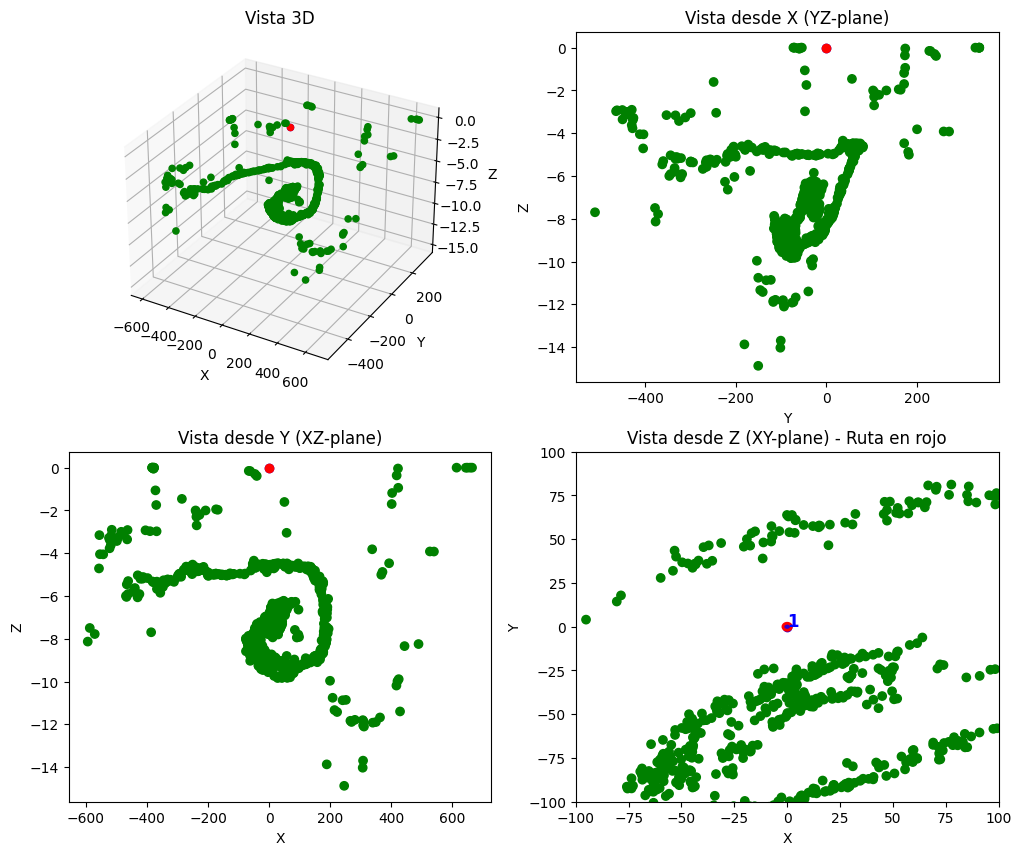

Tiempo de la ruta (s): 75.00074143521488
INDICES DETECTADOS = 8.0


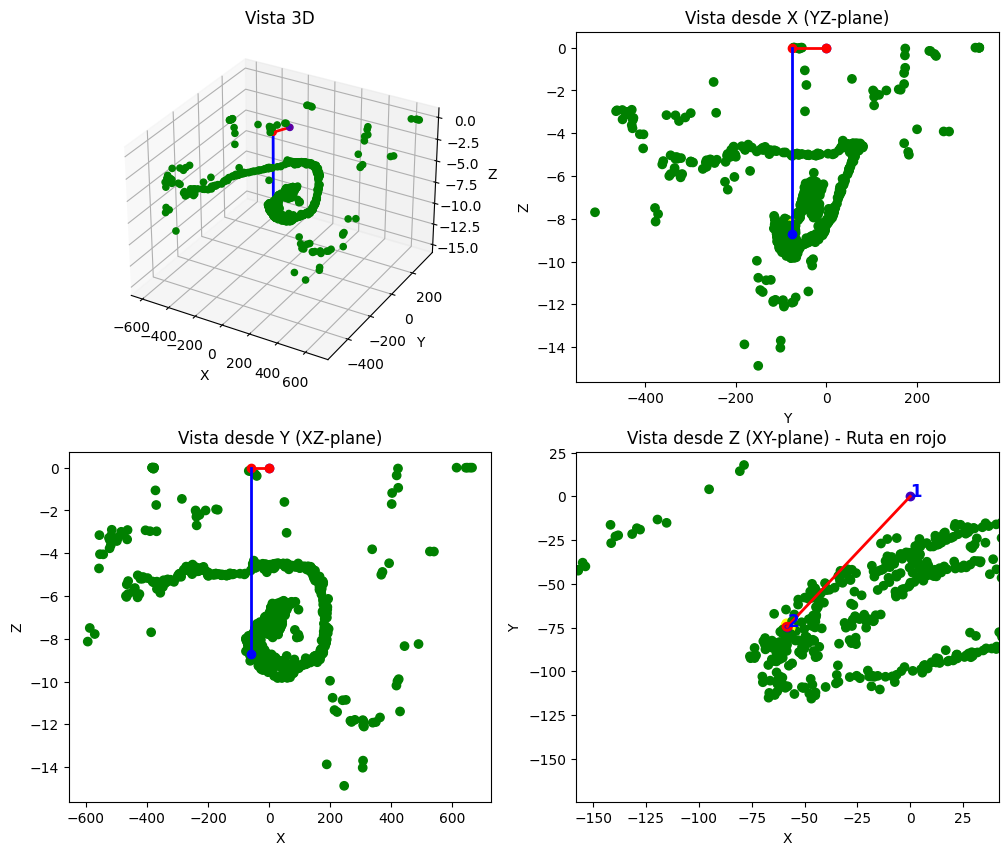

Tiempo de la ruta (s): 146.8466236529639
INDICES DETECTADOS = 15.0


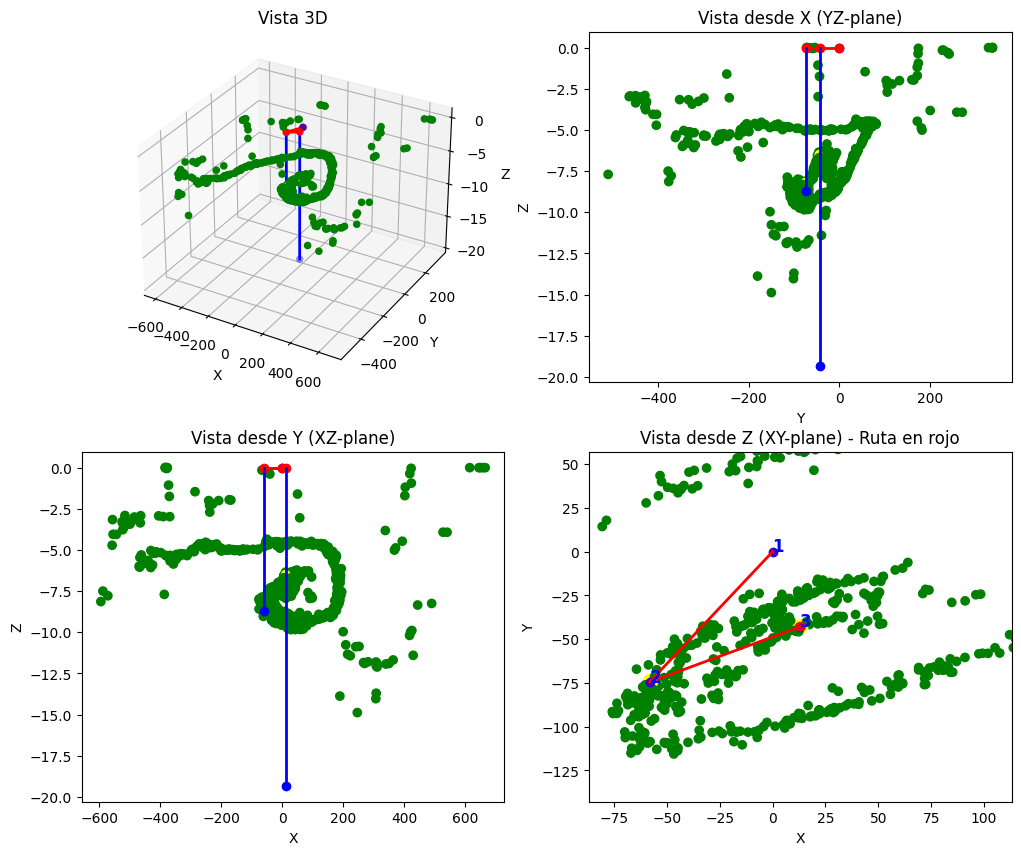

Tiempo de la ruta (s): 224.85758566152072
INDICES DETECTADOS = 22.0


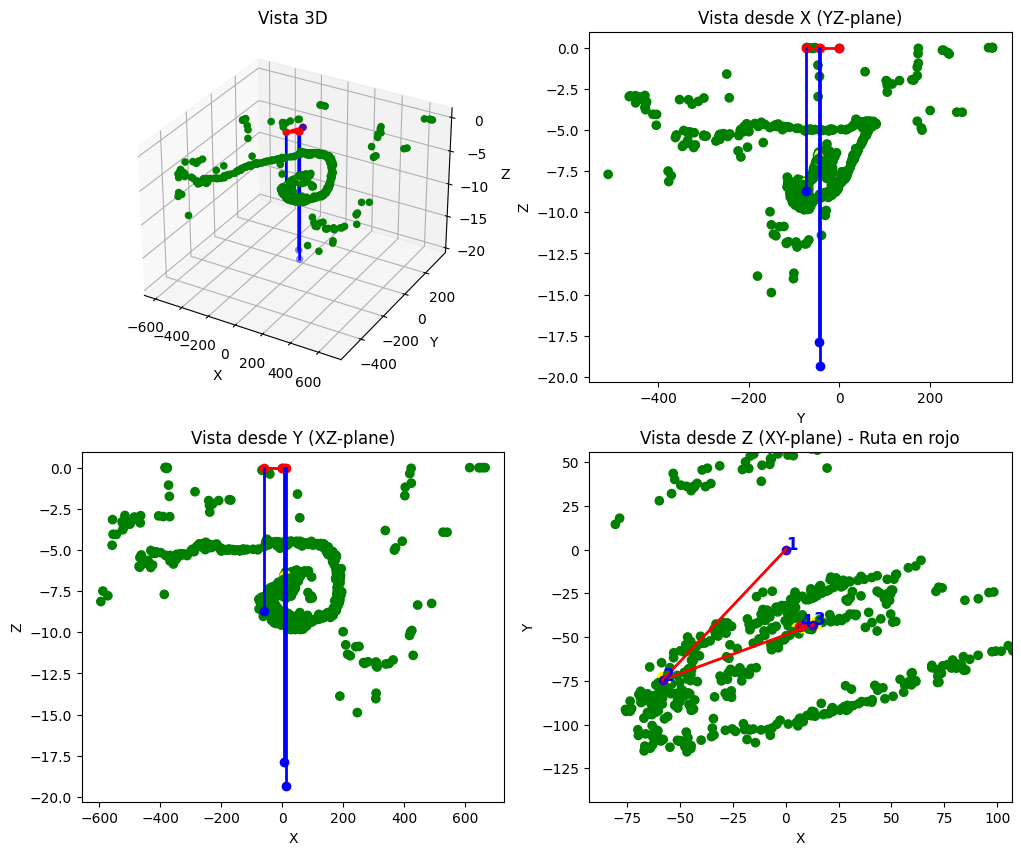

Tiempo de la ruta (s): 258.20864443288883
INDICES DETECTADOS = 27.0


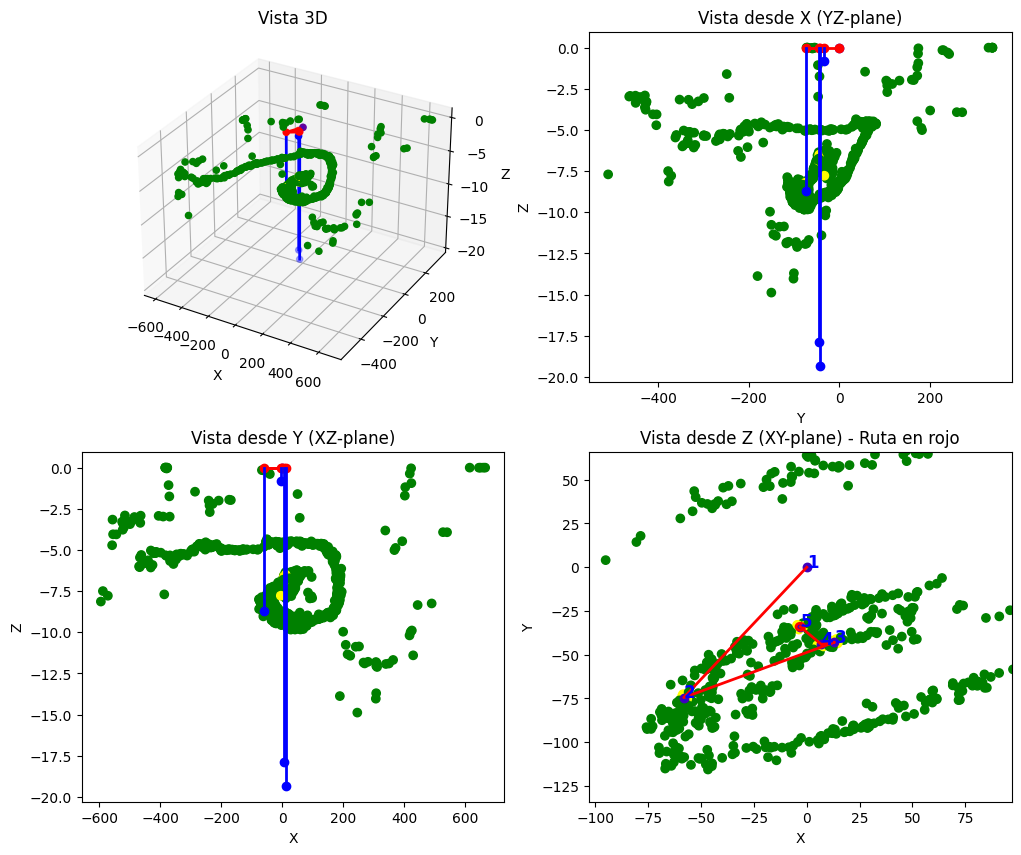

Tiempo de la ruta (s): 270.5076477242983
INDICES DETECTADOS = 35.0


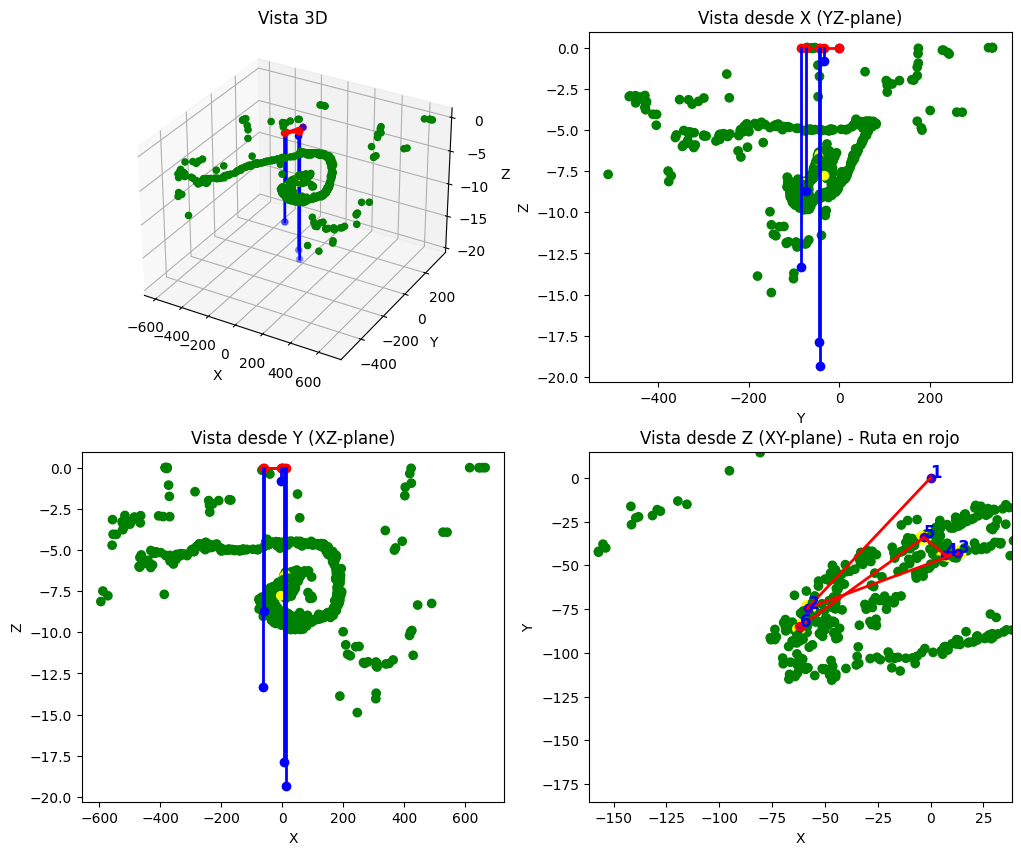

Tiempo de la ruta (s): 276.8557250642334
INDICES DETECTADOS = 39.0


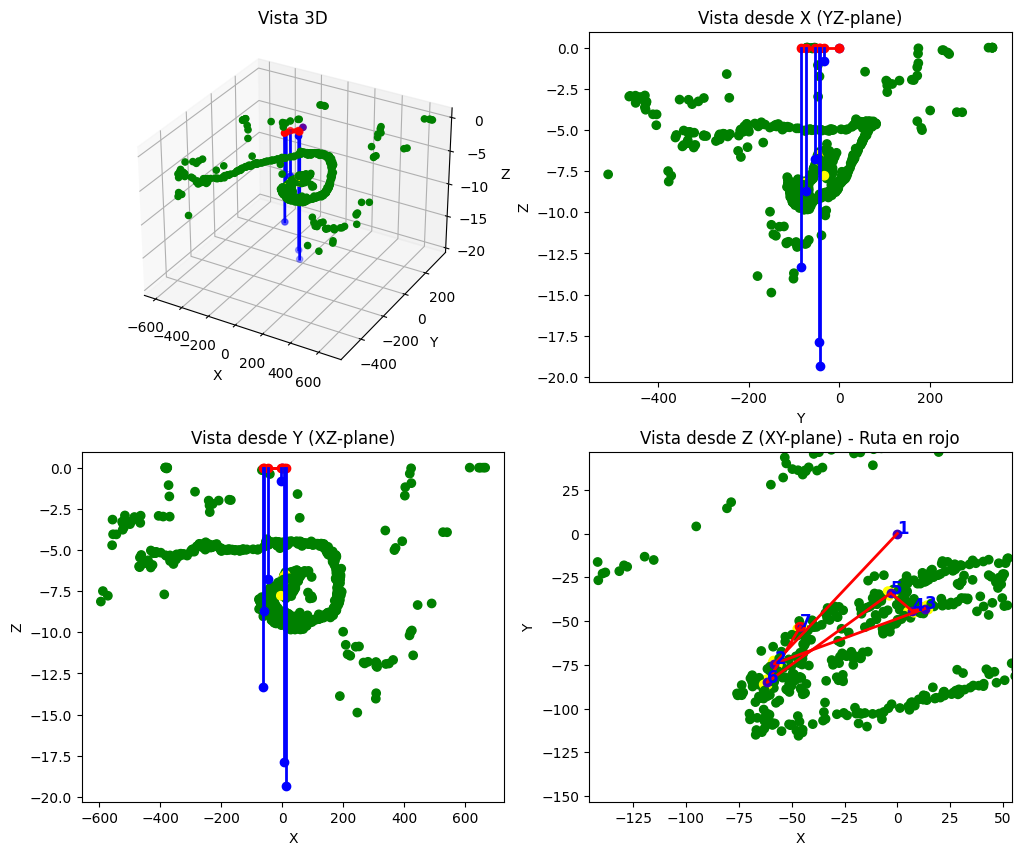

Tiempo de la ruta (s): 278.7393016065471
INDICES DETECTADOS = 42.0


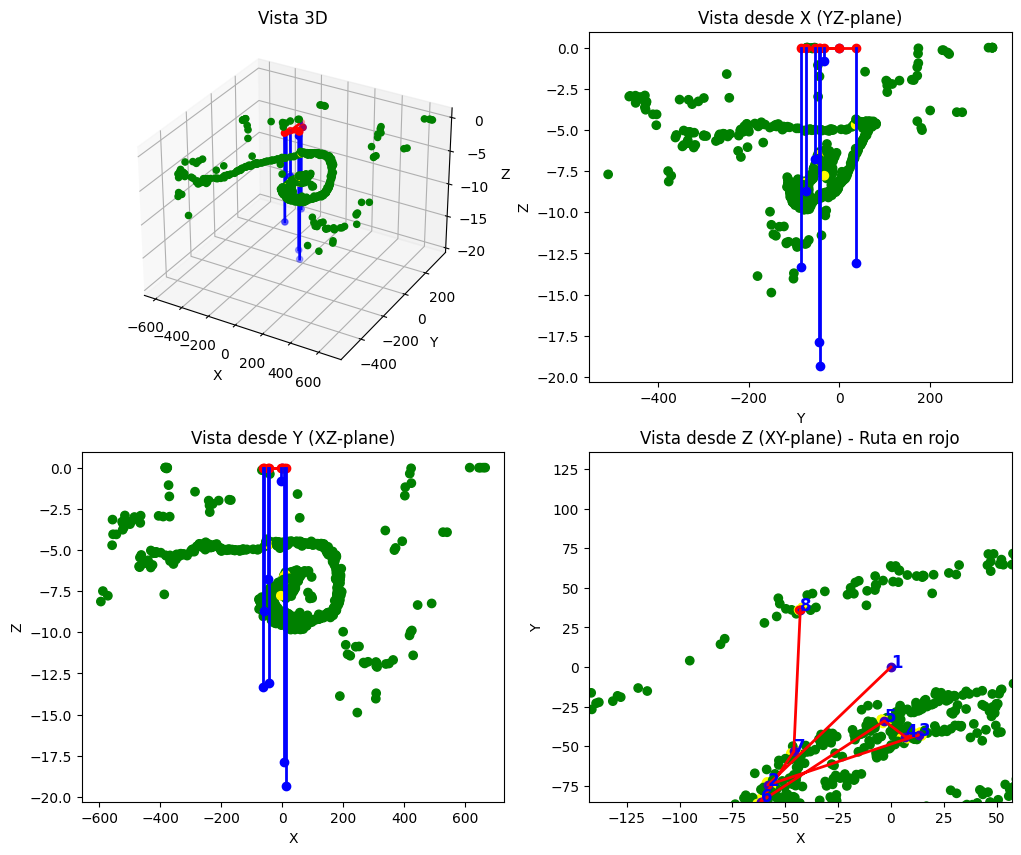

Tiempo de la ruta (s): 288.78264804545324
INDICES DETECTADOS = 44.0


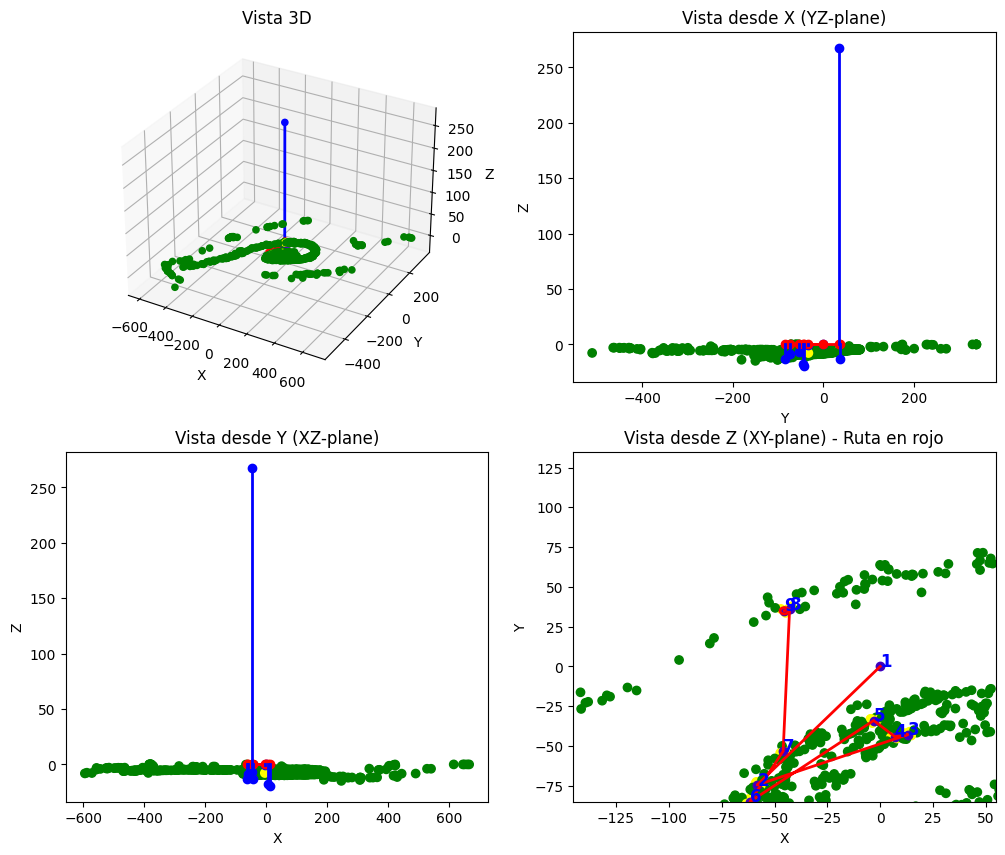

Tiempo de la ruta (s): 302.9567475558724
INDICES DETECTADOS = 44.0


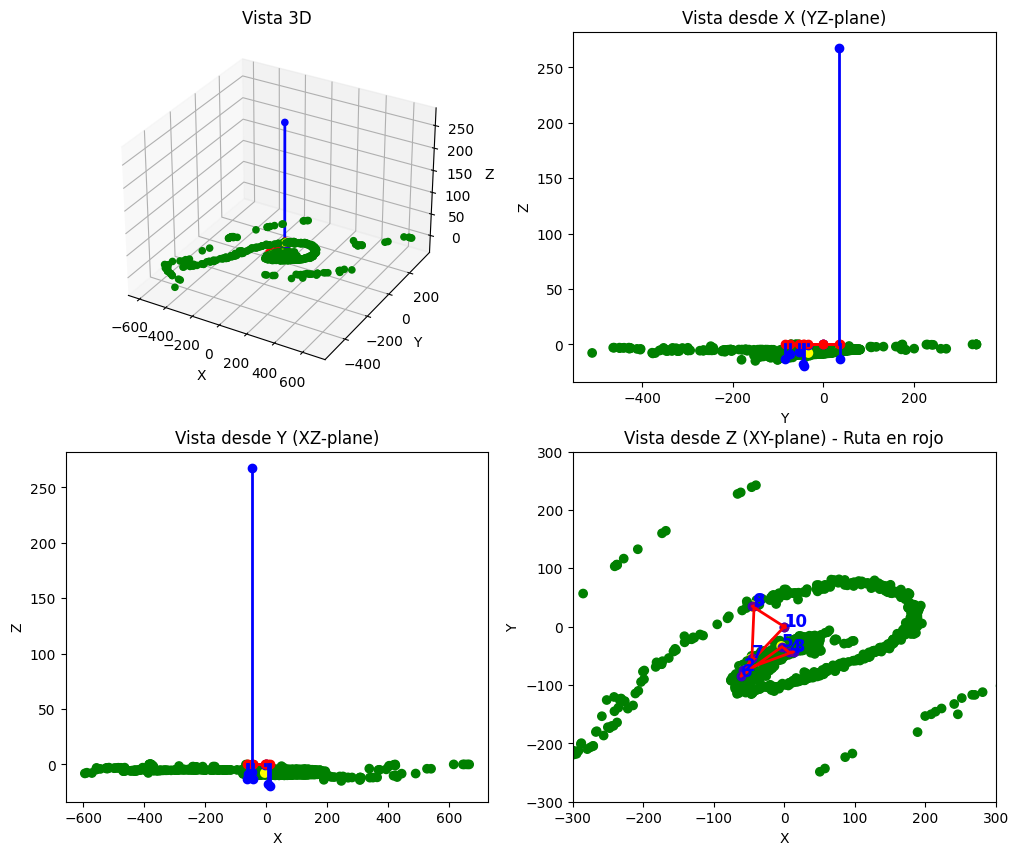

array([93600.        , 93601.25001236, 93602.44744373, 93603.74762643,
       93604.30347741, 93604.5084608 , 93604.61426208, 93604.64565503,
       93604.81304413, 93605.04927913])

In [31]:
import numpy as np
import matplotlib.pyplot as plt

ind_mejor_individuo = np.argmin(result.F[:,1])
print(mejor_individuo)
mejor_individuo = result.X[ind_mejor_individuo]
mapa_mejor = mapa_dinamico_detecciones
# indice_min_segundo_objetivo = np.argmin(result.F[:, 1])

# # Obtener el individuo correspondiente
# mejor_individuo = result.X[indice_min_segundo_objetivo]

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []

for i in range(len(tiempos_ruta)):
    p1 = [mejor_individuo[i], mejor_individuo[i+1], mejor_individuo[i+2]]
    p2 = [mejor_individuo[i+3], mejor_individuo[i+4], mejor_individuo[i+5]]
    zeros.append(0)
    
    # Cálculo de tiempos de la ruta
    if i == 0:
        tiempos_ruta[i] = tVec_min[0, 0]
    else:
        tiempos_ruta[i] = tiempos_ruta[i - 1] + calcular_distancia(p1, p2) / (v_media * 60)  # v_media en m/min
    
    dif_tVec_tAct = np.abs(tVec_min - tiempos_ruta[i])
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"Tiempo de la ruta (s): {(tiempos_ruta[i]-tiempos_ruta[0])*60}")

    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]

    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    print(f"INDICES DETECTADOS = {np.sum(indices_detectados_i)}")
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])

    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')  # Puntos en 3D
    ax1.scatter(x, y, zeros, c='r', marker='o')  # Puntos proyectados en rojo (Z=0)

    # Líneas rojas entre los puntos proyectados en el suelo (Z=0)
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules entre cada punto rojo (proyección) y su correspondiente punto azul en 3D
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")

    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (YZ)
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")

    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (XZ)
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")

    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha = 0.2)

    # Línea roja conectando los puntos XY
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)

    # Dibujar un círculo en el punto actual
    radio = 2  # Define el radio del círculo según lo necesites
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)  # Agregar el círculo al gráfico
    for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
        ax4.text(xi, yi, str(idx+1), color='blue', fontsize=12, fontweight='bold')  # Vista XY
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")
    if(i < len(tiempos_ruta)-1 ):
        ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
        ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    else:
        ax4.set_xlim(min(x[0] - 300, min(x)), max(x[0] + 300, max(x)))
        ax4.set_ylim(min(y[0] - 300, min(y)), max(y[0] + 300, max(y)))

    # Añadir etiquetas numeradas para cada punto visitado

    plt.show()
    plt.pause(0.1)  # Pequeña pausa para visualizar correctamente
    
    j += 3

tiempos_ruta  # Esta línea muestra los tiempos de la ruta


[  0.           0.           0.           2.27367414 -36.87019578
 -16.1529348   13.34614388 -42.09727891 -16.65154261 128.25257964
 -42.63001826 -11.03657674 125.28354287 -43.45808469 -16.84246348
 -62.06792017 -85.17279711 -10.22254406 -14.36482802 -42.85516758
   0.          28.44630136 -18.75566748 -19.46596451   6.90335662
 -44.09063345 -78.56009685   0.           0.           0.        ]
Tiempo de la ruta (s): 0.0
INDICES DETECTADOS = 0.0


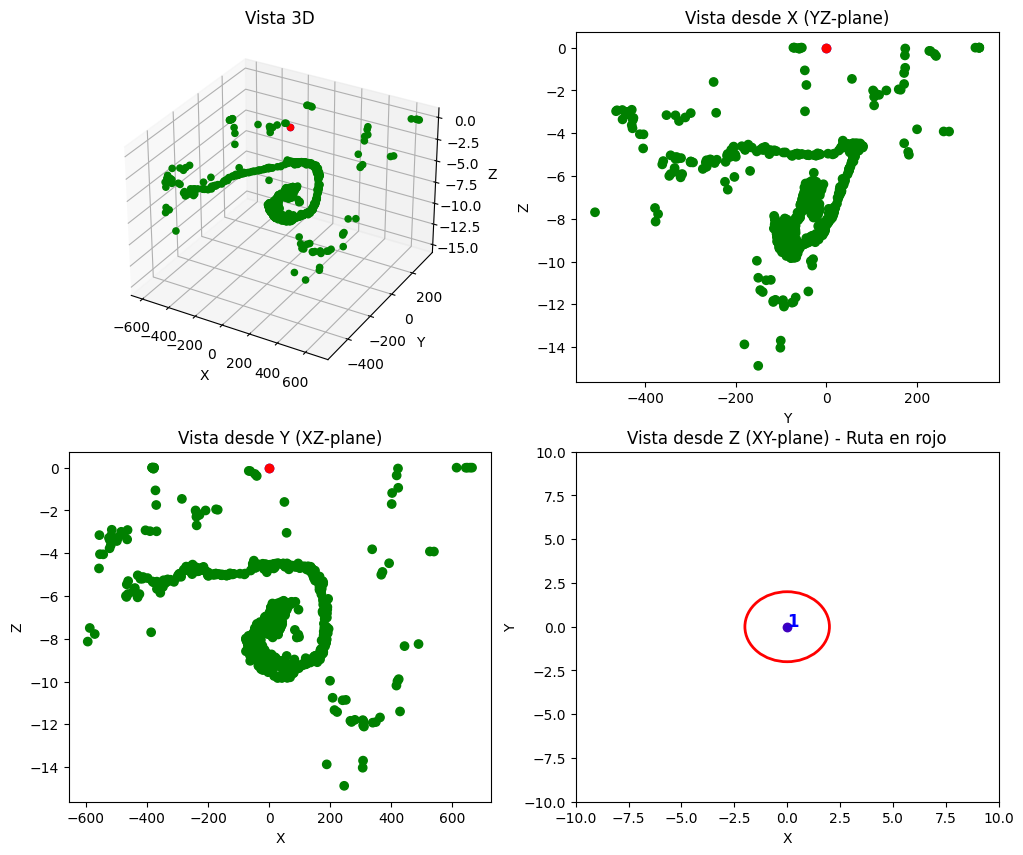

Tiempo de la ruta (s): 40.253305946826
INDICES DETECTADOS = 7.0


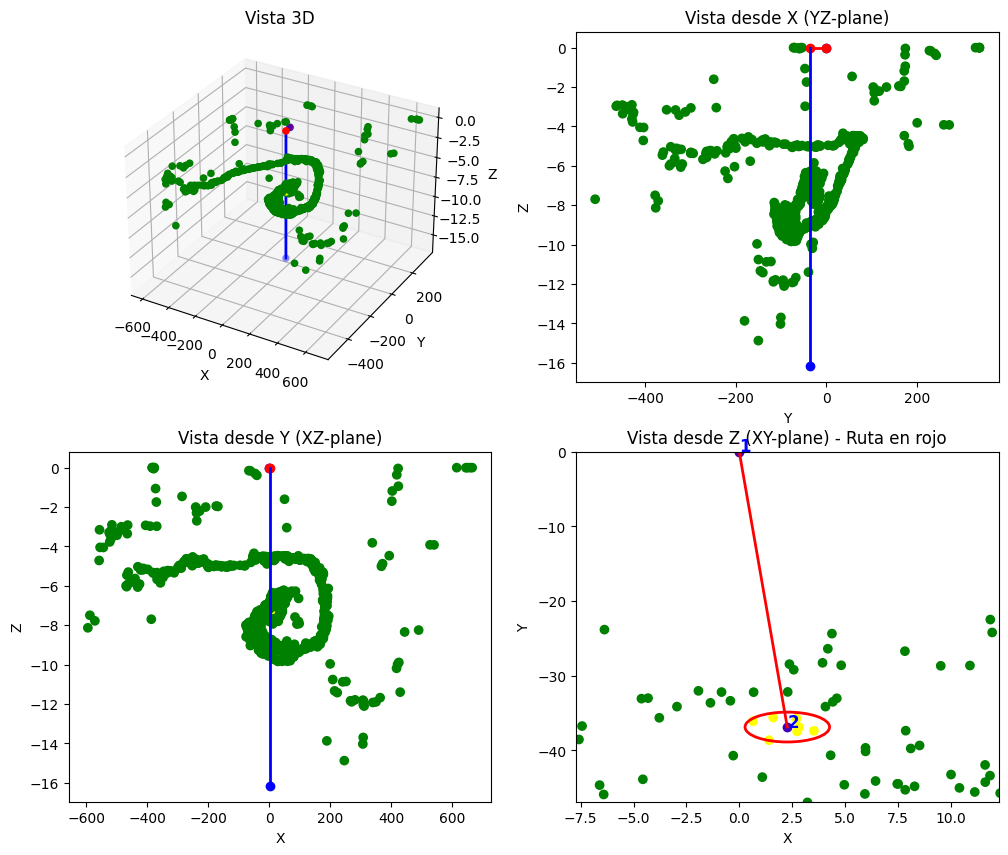

Tiempo de la ruta (s): 59.83689317072276
INDICES DETECTADOS = 13.0


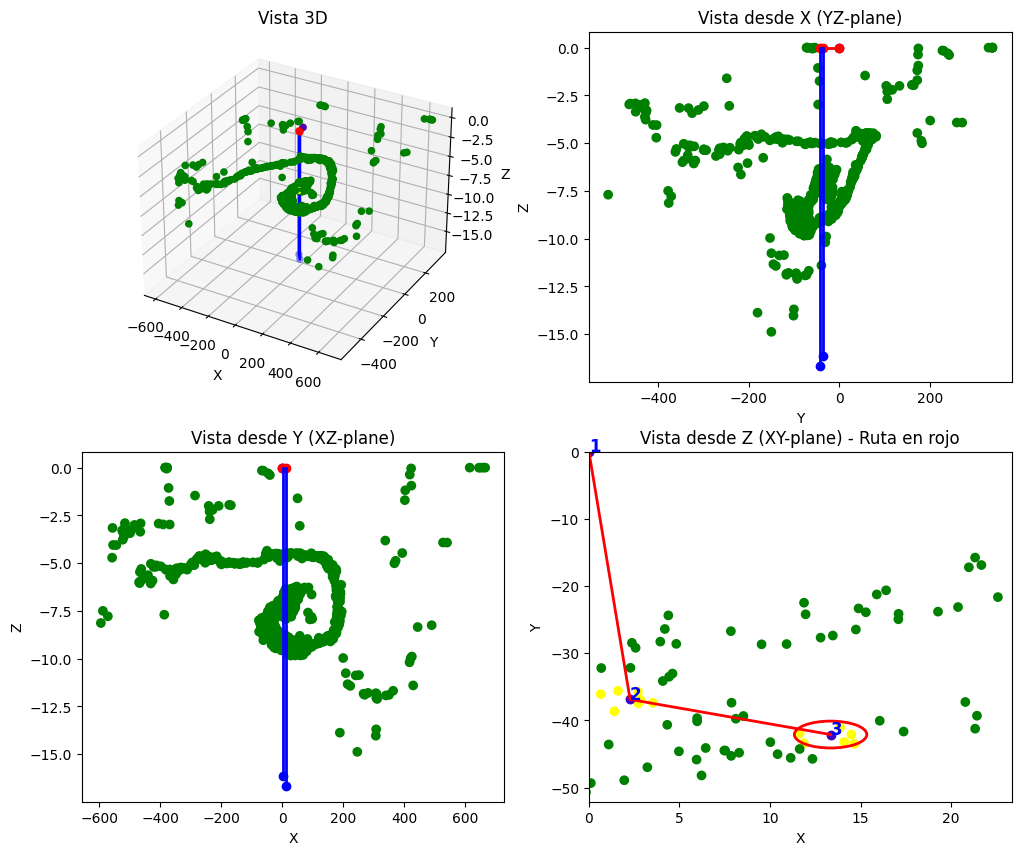

Tiempo de la ruta (s): 72.08115648158127
INDICES DETECTADOS = 17.0


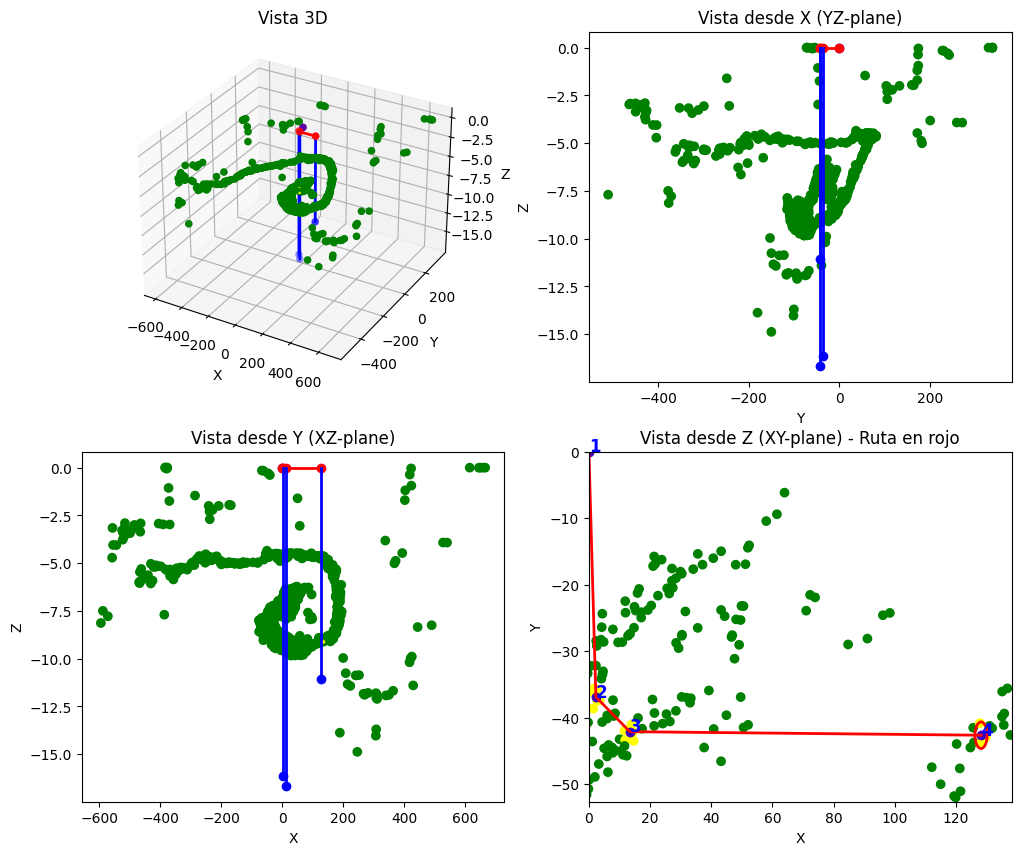

Tiempo de la ruta (s): 77.33196668035816
INDICES DETECTADOS = 20.0


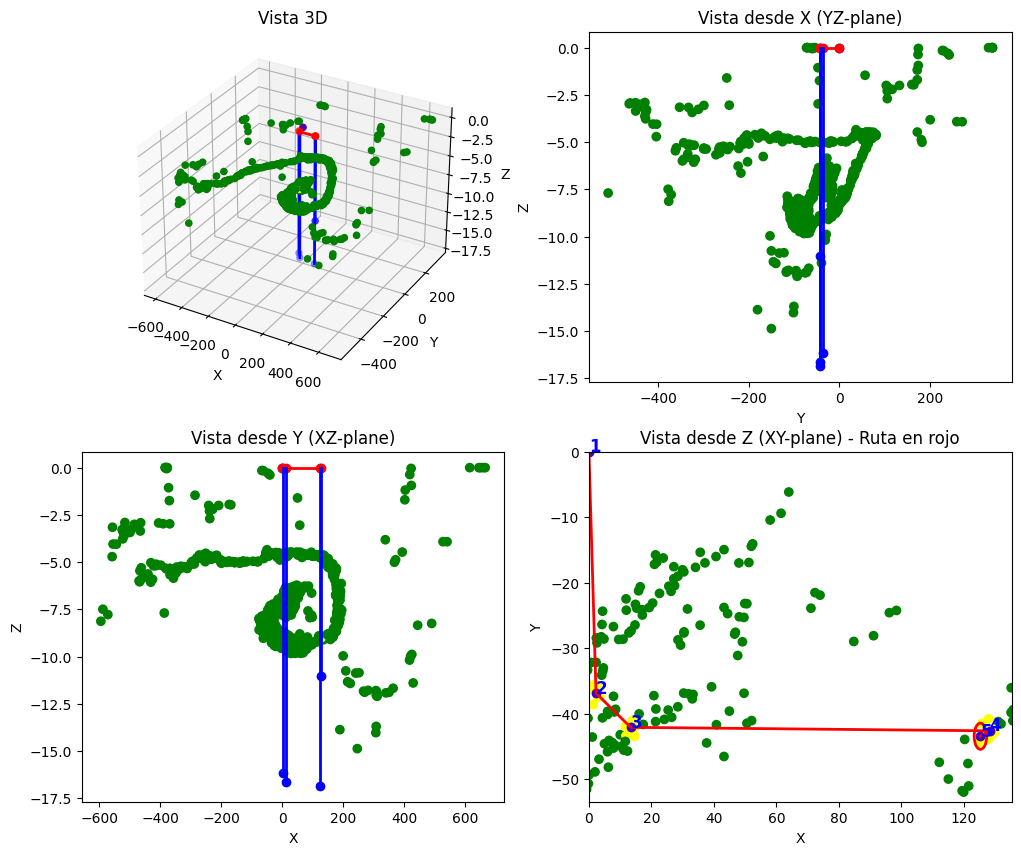

Tiempo de la ruta (s): 192.23948423168622
INDICES DETECTADOS = 29.0


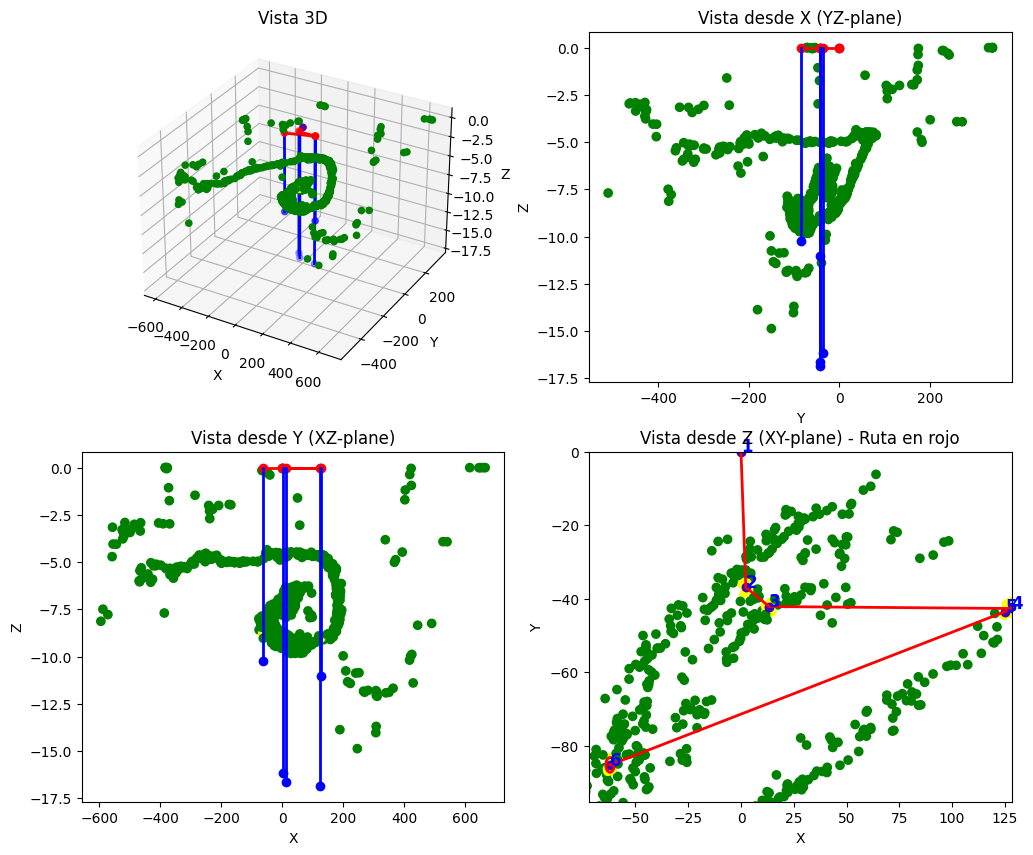

Tiempo de la ruta (s): 307.14715495618293
INDICES DETECTADOS = 33.0


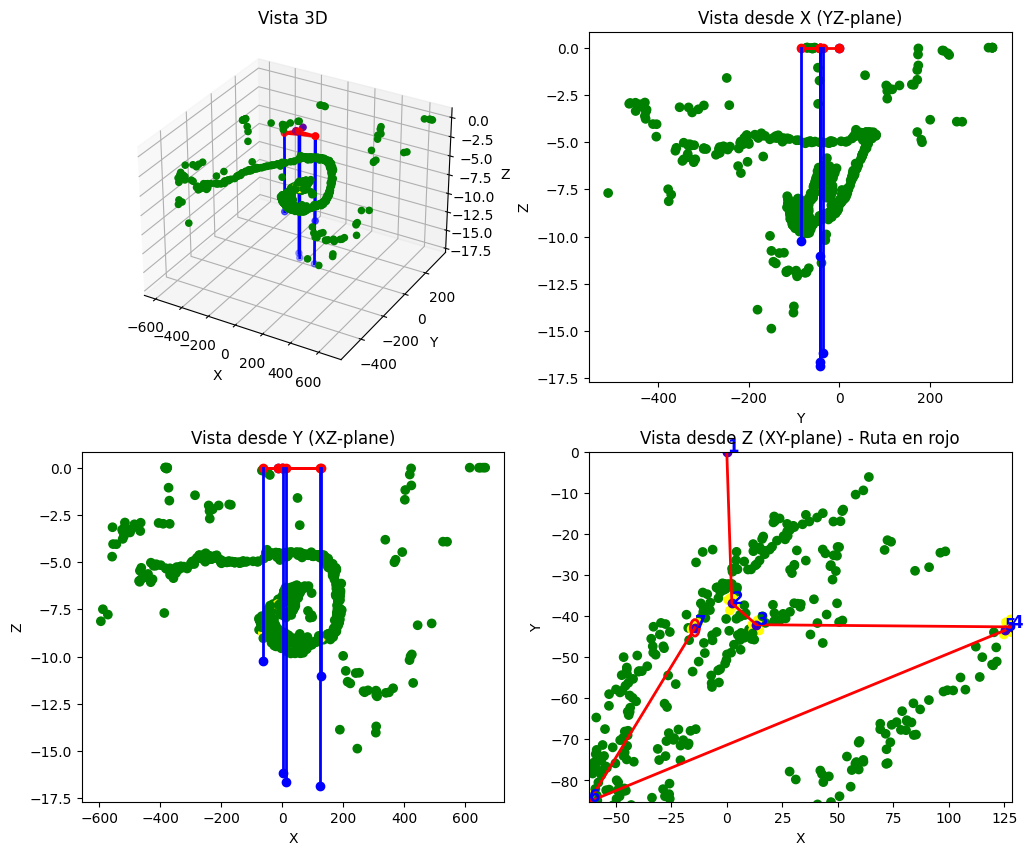

Tiempo de la ruta (s): 312.7873369472218
INDICES DETECTADOS = 39.0


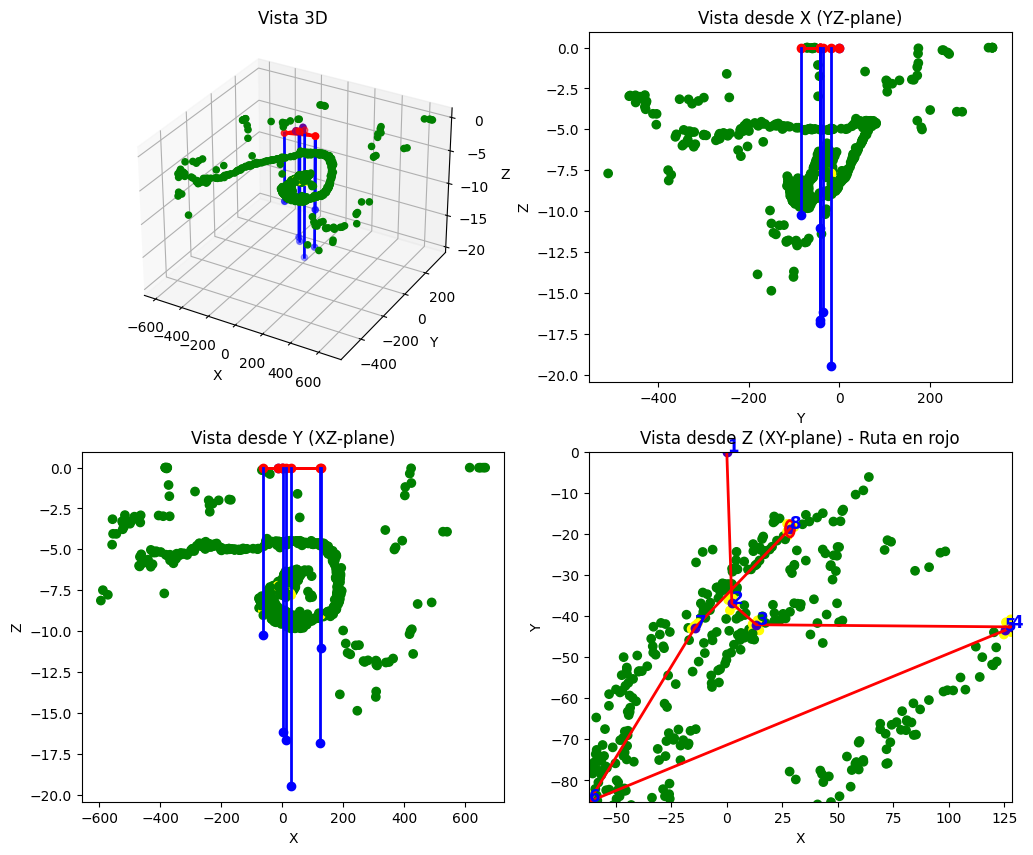

Tiempo de la ruta (s): 319.1389525687555
INDICES DETECTADOS = 46.0


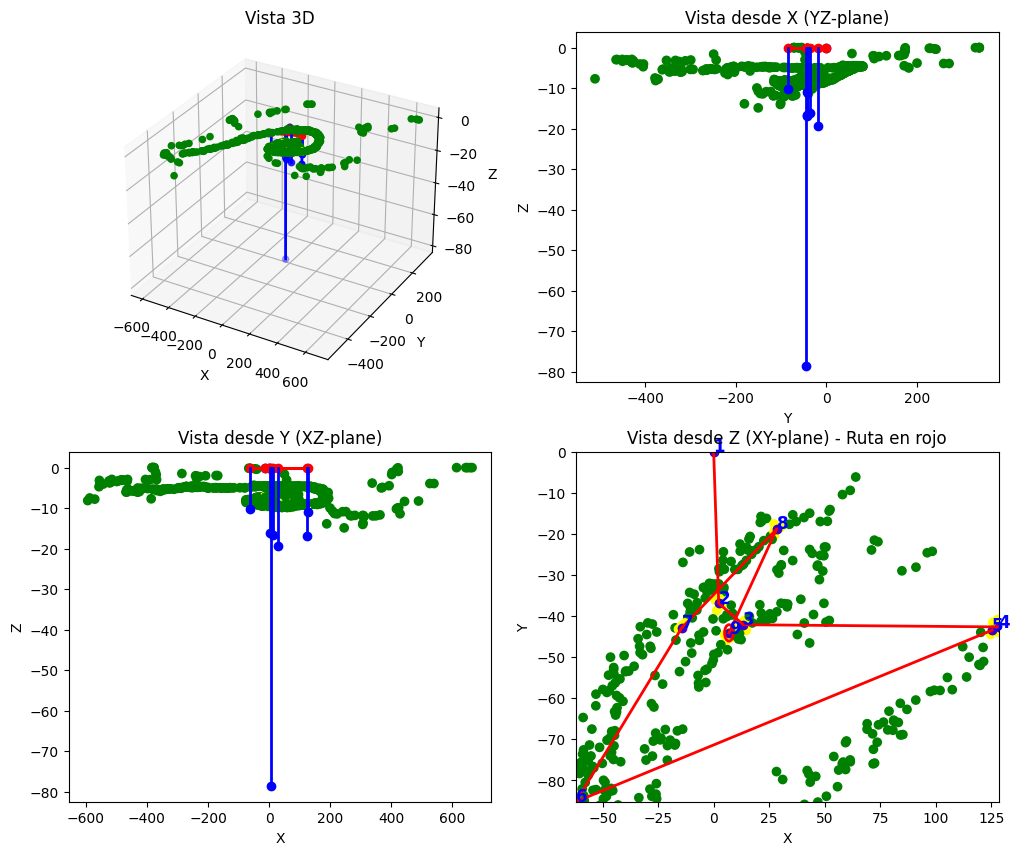

Tiempo de la ruta (s): 322.22130124020623
INDICES DETECTADOS = 46.0


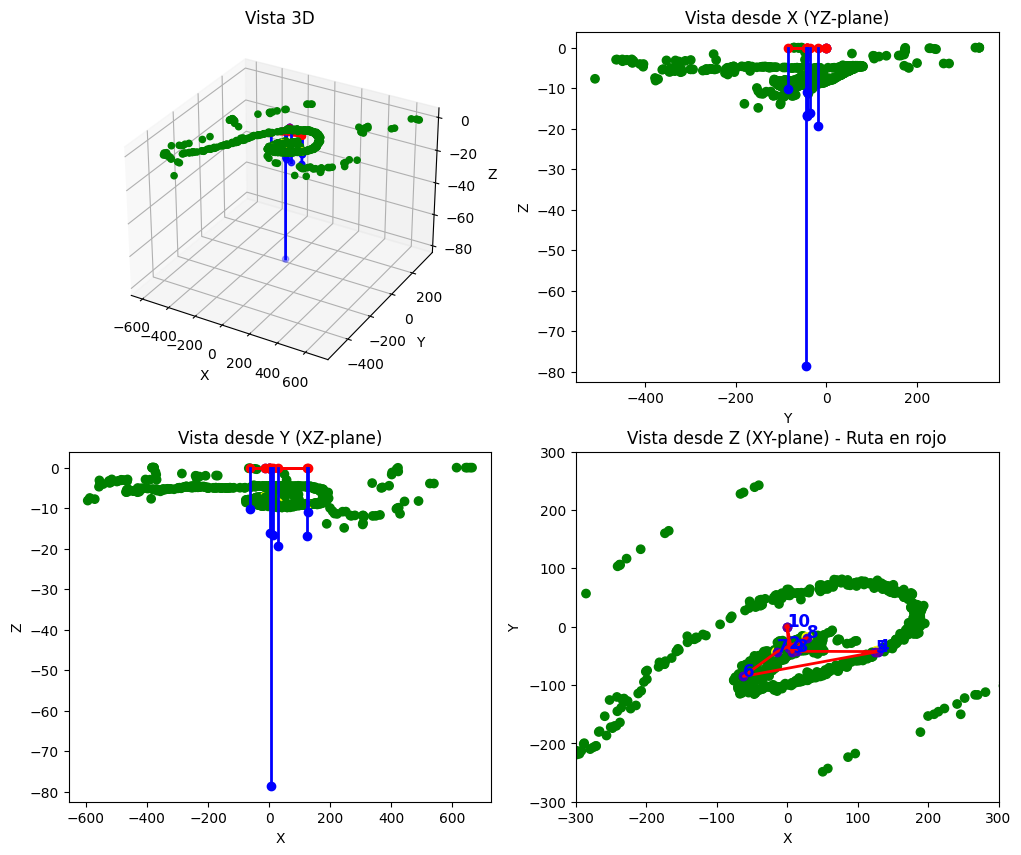

array([93600.        , 93600.67088843, 93600.99728155, 93601.20135261,
       93601.28886611, 93603.2039914 , 93605.11911925, 93605.21312228,
       93605.31898254, 93605.37035502])

In [84]:
import numpy as np
import matplotlib.pyplot as plt

ind_mejor_individuo = np.argmin(result.F[:,1])
print(mejor_individuo)
mejor_individuo = result.X[ind_mejor_individuo]
mapa_mejor = mapa_dinamico_detecciones
# indice_min_segundo_objetivo = np.argmin(result.F[:, 1])

# # Obtener el individuo correspondiente
# mejor_individuo = result.X[indice_min_segundo_objetivo]

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []

for i in range(len(tiempos_ruta)):
    p1 = [mejor_individuo[i], mejor_individuo[i+1], mejor_individuo[i+2]]
    p2 = [mejor_individuo[i+3], mejor_individuo[i+4], mejor_individuo[i+5]]
    zeros.append(0)
    
    # Cálculo de tiempos de la ruta
    if i == 0:
        tiempos_ruta[i] = tVec_min[0, 0]
    else:
        tiempos_ruta[i] = tiempos_ruta[i - 1] + calcular_distancia(p1, p2) / (v_media * 60)  # v_media en m/min
    
    dif_tVec_tAct = np.abs(tVec_min - tiempos_ruta[i])
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"Tiempo de la ruta (s): {(tiempos_ruta[i]-tiempos_ruta[0])*60}")

    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]

    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    print(f"INDICES DETECTADOS = {np.sum(indices_detectados_i)}")
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])

    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')  # Puntos en 3D
    ax1.scatter(x, y, zeros, c='r', marker='o')  # Puntos proyectados en rojo (Z=0)

    # Líneas rojas entre los puntos proyectados en el suelo (Z=0)
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules entre cada punto rojo (proyección) y su correspondiente punto azul en 3D
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")

    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (YZ)
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")

    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (XZ)
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")

    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha = 0.2)

    # Línea roja conectando los puntos XY
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)

    # Dibujar un círculo en el punto actual
    radio = 2  # Define el radio del círculo según lo necesites
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)  # Agregar el círculo al gráfico
    for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
        ax4.text(xi, yi, str(idx+1), color='blue', fontsize=12, fontweight='bold')  # Vista XY
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")
    if(i < len(tiempos_ruta)-1 ):
        ax4.set_xlim(min(x[-1] - 10, min(x)), max(x[-1] + 10, max(x)))
        ax4.set_ylim(min(y[-1] - 10, min(y)), max(y[-1] + 10, max(y)))
    else:
        ax4.set_xlim(min(x[0] - 300, min(x)), max(x[0] + 300, max(x)))
        ax4.set_ylim(min(y[0] - 300, min(y)), max(y[0] + 300, max(y)))

    # Añadir etiquetas numeradas para cada punto visitado

    plt.show()
    plt.pause(0.1)  # Pequeña pausa para visualizar correctamente
    
    j += 3

tiempos_ruta  # Esta línea muestra los tiempos de la ruta


In [12]:
ind = np.argmin(result.F[:,1])
ind

0

In [11]:
result.F[:,1]

array([-10.,  -1., -10.,  -4.,  -2.,  -5.,  -7.,  -7.,  -3.,  -6.,  -5.,
        -6.,  -5.,  -6.,  -6.,  -6.,  -6.,  -5.,  -5.,  -6.,  -5.,  -5.,
        -5.,  -6.,  -5.,  -5.,  -6.,  -6.,  -5.,  -6.,  -5.,  -5.,  -6.,
        -5.,  -6.,  -6.,  -5.,  -6.,  -6.,  -6.,  -5.,  -6.,  -6.,  -6.,
        -6.,  -5.,  -6.,  -6.,  -5.,  -6.,  -5.,  -7.,  -6.,  -5.,  -5.,
        -6.,  -5.,  -5.,  -5.,  -6.,  -6.,  -6.,  -6.,  -6.,  -5.,  -5.,
        -6.,  -6.,  -6.,  -6.,  -5.,  -6.,  -5.,  -6.,  -6.,  -6.,  -5.,
        -6.,  -5.,  -5.,  -5.,  -6.,  -5.,  -6.,  -6.,  -6.,  -6.,  -6.,
        -6.,  -6.,  -6.,  -6.,  -6.,  -6.,  -5.,  -6.,  -6.,  -6.,  -5.,
        -6.,  -6.,  -5.,  -5.,  -6.,  -6.,  -6.,  -6.,  -6.,  -6.,  -6.,
        -6.,  -6.,  -6.,  -5.,  -5.,  -6.,  -6.,  -5.,  -6.,  -5.,  -6.,
        -6.,  -5.,  -6.,  -5.,  -6.,  -6.,  -6.,  -6.,  -6.,  -5.,  -6.,
        -5.,  -6.,  -5.,  -6.,  -5.,  -6.,  -5.,  -6.,  -6.,  -6.,  -6.,
        -5.,  -6.,  -6.,  -7.,  -6.,  -6.,  -6.,  -